 The following cells are the analyses of the experiment data we gathered during *Tag der offenen Tür* on 23.01.26

In [1]:
import pandas as pd
import glob
import os
import ast
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# MERGING ALL CSVS TO ONE DF
li = []
path = os.path.join("results_ai-chorales")
all_files = glob.glob(os.path.join(path, "*.csv"))
for filename in all_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    li.append(df)
frame = pd.concat(li, axis=0, ignore_index=True)
frame

,rt,response,trial_type,trial_index,plugin_version,time_elapsed,correct,training,stimulus,correct_response,timestamp
0,3251,"{""age"":""15""}",survey-text,1,2.1.0,57779,NaN,NaN,NaN,NaN,NaN
1,8680,m,audio-keyboard-response,6,2.1.0,103659,m,True,data/H/244.15-6.wav,True,NaN
2,3840,x,audio-keyboard-response,8,2.1.0,111010,x,True,data/A/output31-5.wav,True,NaN
3,8021,m,audio-keyboard-response,10,2.1.0,122355,x,False,data/A/output19-1.wav,NaN,2026-01-23T14-02-56-171Z
4,34699,x,audio-keyboard-response,11,2.1.0,157659,m,False,data/H/227.11-5.wav,NaN,2026-01-23T14-02-56-171Z
...,...,...,...,...,...,...,...,...,...,...,...
835,9371,x,audio-keyboard-response,26,2.1.0,342899,m,False,data/H/153.5-3.wav,NaN,2026-01-23T14-21-34-148Z
836,7648,m,audio-keyboard-response,27,2.1.0,351235,m,False,data/H/244.15-6.wav,NaN,2026-01-23T14-21-34-148Z
837,11331,m,audio-keyboard-response,28,2.1.0,363124,x,False,data/A/output3-3.wav,NaN,2026-01-23T14-21-34-148Z
838,8381,m,audio-keyboard-response,29,2.1.0,372059,m,False,data/H/292-2.wav,NaN,2026-01-23T14-21-34-148Z


Average age: 24.2


<Axes: xlabel='age'>

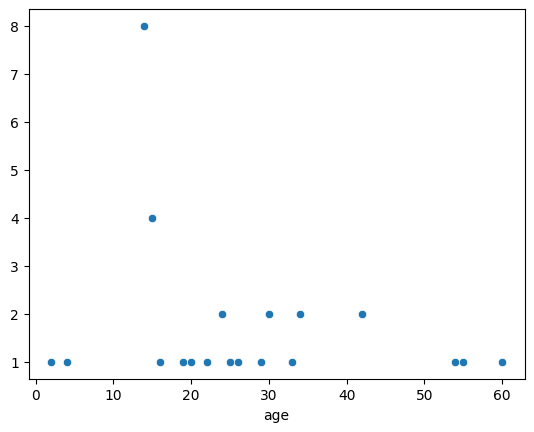

In [13]:
# ===========
# AVERAGE AGE
# ===========

age_list = []
for answers in frame["response"]:
    if isinstance(answers, str):
        try:
            parsed = ast.literal_eval(answers) 
            if isinstance(parsed, dict): # convert the strings to real dicts
                if "age" in parsed:
                    age_list.append(parsed)
        except (ValueError, SyntaxError):
            pass
df_age = pd.DataFrame(age_list)
df_age["age"] = pd.to_numeric(df_age["age"], errors="coerce")

df_age = df_age[
    (df_age["age"] >= 0) & 
    (df_age["age"] <= 100)
]
print("Average age:", round(df_age["age"].mean(), 1))

counts = df_age["age"].value_counts().sort_index()

sns.scatterplot(x=counts.index, y=counts.values)


In [5]:
# ===================
# DISPLAY Q-RESPONSES
# ===================
for answers in frame["response"]:
    if isinstance(answers, str):
        try:
            parsed = ast.literal_eval(answers) 
            if isinstance(parsed, dict): # convert the strings to real dicts
                if "Q0" in parsed and parsed["Q0"]:
                    print(parsed)
        except (ValueError, SyntaxError):
            pass

{'Q0': 'Megacoool und super innovativ, habt ihr echt super gemacht :)'}
{'Q0': 'Es ist etwas schwierig zu unterscheiden zwischen KI & Mensch gemachte Musik, man kennt aber irgendwie den Muster. ist ein sehr gutes Experiment.'}
{'Q0': 'scho schwer\n'}
{'Q0': 'sehr schwer, auch weil alle Stücke sehr ähnlich klangen'}
{'Q0': 'sehr schwer aber gut:)'}
{'Q0': 'schwierig und ohne Bachkenntnisse kaum lösbar'}
{'Q0': 'Es hat Spaß gemacht und es wurde gut erklärt und war einfach zu verstehen und umzusetzen. Aber vllt kann man so nach 10 kurz pause machen, weil man sich dann nicht mehr so gut konzentrieren kann und davor einen tipp geben auf was man achten kann.'}
{'Q0': 'schwierig aber spassig :)'}
{'Q0': 'Sehr schöner Test'}
{'Q0': 'schwer\n'}
{'Q0': 'die lieder klangen alle sehr gleich'}
{'Q0': 'es hat total spaß gemacht auch wenn ich denke dass ich ziemlich viel falsch getippt habe. War eine super Erfahrung, da ich das ganze Thema rund um KI super spannend finde.'}
{'Q0': 'sehr gut\n'}
{'Q0'

In [20]:
# =================
# AVG REACTION TIME
# =================

react_time_avg = frame["rt"].mean() / 1000

print(f"The average reaction time in the experiment was {"%.2f" % react_time_avg} seconds")

The average reaction time in the experiment was 9.65 seconds
